In [4]:
from tensorflow import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np

In [5]:
import tensorflow as tf

In [6]:
print(tf.__version__)

2.20.0


In [7]:
(x_train, _), (x_test, _) = mnist.load_data()

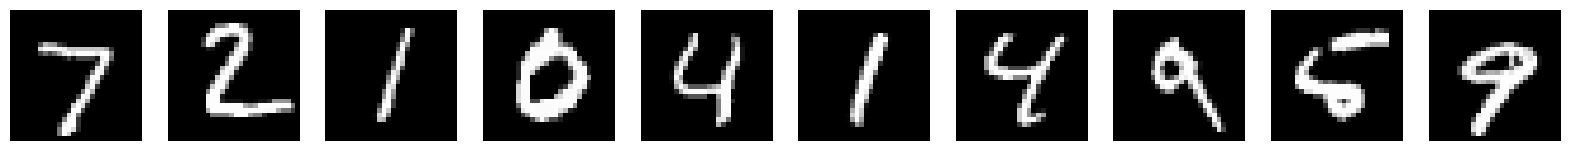

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

n = 10  # number of images
plt.figure(figsize=(20, 4))  # better size

for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')  # no reshape needed
    ax.axis('off')

plt.show()

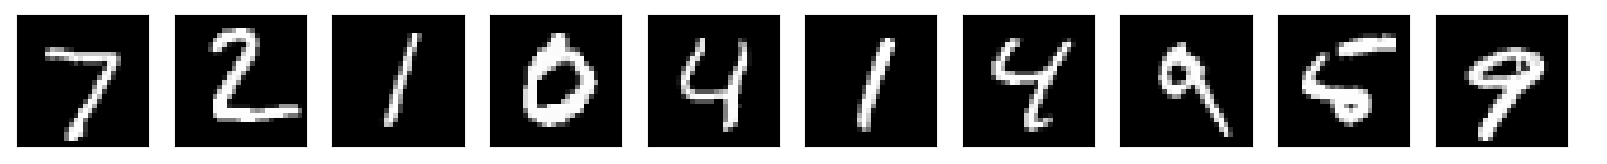

In [10]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, UpSampling2D, Reshape

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

encode_model = Sequential()

############
# Encoding #
############

# FIRST BLOCK
encode_model.add(Conv2D(filters=16, kernel_size=(3,3),
                        input_shape=(28, 28, 1),
                        activation='relu',
                        padding='same'))

encode_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))

# SECOND BLOCK
encode_model.add(Conv2D(filters=8, kernel_size=(3,3),
                        activation='relu',
                        padding='same'))

encode_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))

# Flatten
encode_model.add(Flatten())

# Dense layers
encode_model.add(Dense(7*7*8, activation="relu"))
encode_model.add(Dense(30, activation="relu"))  # latent space

print(encode_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 392)            │       154,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │        11,790 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,166 (652.99 KB)

 Trainable params: 167,166 (652.99 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
############
# Decoding #
############
decode_model=Sequential()

decode_model.add(Dense(7*7*8,activation="relu"))
decode_model.add(Reshape([7,7,8]))

# DeConv1
decode_model.add(Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same'))
# Upsampling LAYER
decode_model.add(UpSampling2D((2, 2)))

# Deconv2
decode_model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same'))
# POOLING LAYER
decode_model.add(UpSampling2D((2, 2)))

decode_model.add(Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same'))


ENCODER:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 392)            │       154,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │        11,790 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,166 (652.99 KB)

 Trainable params: 167,166 (652.99 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 30)             │       167,166 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │        14,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,215 (707.87 KB)

 Trainable params: 181,215 (707.87 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.8068 - loss: 0.3225 - val_accuracy: 0.8072 - val_loss: 0.2087
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.7986 - loss: 0.1760 - val_accuracy: 0.7970 - val_loss: 0.1550
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.8017 - loss: 0.1478 - val_accuracy: 0.8019 - val_loss: 0.1409
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8044 - loss: 0.1376 - val_accuracy: 0.8049 - val_loss: 0.1318
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.8060 - loss: 0.1309 - val_accuracy: 0.8058 - val_loss: 0.1274
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8070 - loss: 0.1269 - val_accuracy: 0.8067 - val_loss: 0.1240
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8076 - loss: 0.1241 - val_accuracy: 0.8070 - val_loss: 0.1220
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.8080 - loss: 0.1221 - 

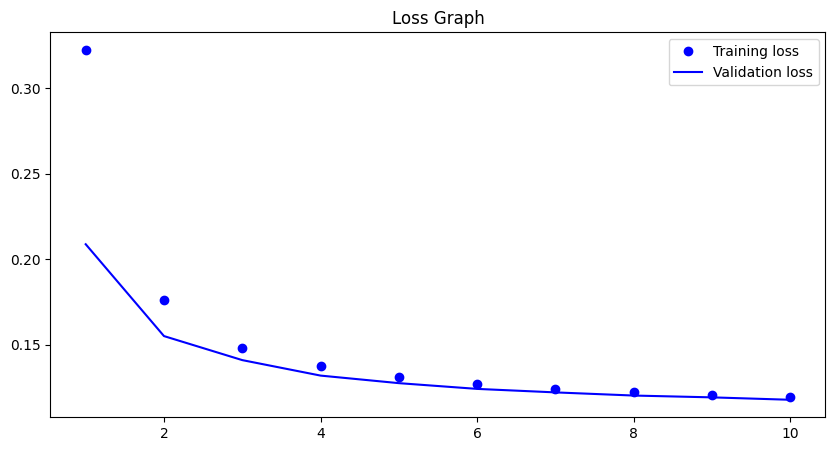

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


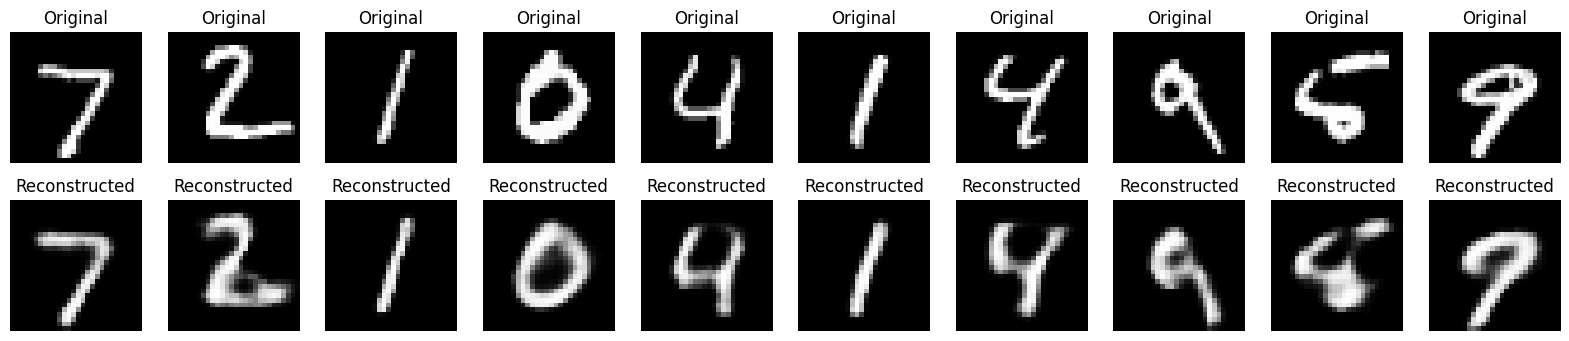

In [17]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Conv2DTranspose,
    Flatten, Dense, Reshape
)

# =========================
# 2. LOAD DATA
# =========================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape for CNN → (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# =========================
# 3. ENCODER
# =========================
encode_model = Sequential()

# Block 1
encode_model.add(Conv2D(16, (3,3), activation='relu', padding='same',
                        input_shape=(28,28,1)))
encode_model.add(MaxPool2D((2,2), padding='same'))

# Block 2
encode_model.add(Conv2D(8, (3,3), activation='relu', padding='same'))
encode_model.add(MaxPool2D((2,2), padding='same'))

# Flatten + Dense
encode_model.add(Flatten())
encode_model.add(Dense(7*7*8, activation='relu'))
encode_model.add(Dense(30, activation='relu'))   # latent space

print("ENCODER:")
encode_model.summary()

# =========================
# 4. DECODER
# =========================
decode = Sequential()

decode.add(Dense(7*7*8, input_shape=(30,), activation='relu'))
decode.add(Reshape((7, 7, 8)))

decode.add(Conv2DTranspose(8, (3,3), strides=2,
                           padding='same', activation='relu'))
decode.add(Conv2DTranspose(16, (3,3), strides=2,
                           padding='same', activation='relu'))

decode.add(Conv2D(1, (3,3), activation='sigmoid', padding='same'))

print("DECODER:")
decode.summary()

# =========================
# 5. AUTOENCODER
# =========================
autoencoder = Sequential([encode_model, decode])

print("AUTOENCODER:")
autoencoder.summary()

# =========================
# 6. COMPILE
# =========================
autoencoder.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# =========================
# 7. TRAIN
# =========================
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# =========================
# 8. LOSS GRAPH
# =========================
losses = history.history['loss']
val_losses = history.history['val_loss']

epochs = range(1, len(losses) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'b', label='Validation loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

# =========================
# 9. RECONSTRUCTION
# =========================
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

In [18]:
encoder.compile(optimizer='adadellta', loss='binary', metrics=['accuracy'])

NameError: name 'encoder' is not defined

In [ ]:
autoecoder.summarize()

In [ ]:
from tensorflow.keras import models

In [ ]:
autoencoder.save('Conv_autoencoder.keras')

In [ ]:
encode_model.summary()

In [ ]:
decode.summary()

In [ ]:
x_train = x_train.reshape(60000,28,28,1)
x_train = x_train/255
x_train.shape()

(60000, 28, 28, 1)

In [ ]:
x_test = x_test.reshape(10000, 28, 28, 1)
x_test = x_test/255
x_test.shape

In [ ]:
# Train the model

history = autoencoder.fit(x=x_train, y=x_train,  epochs=10, batch_size=128, shuffle=True, verbose=1, validation_data=(x_test, y_test))

In [ ]:
losses = history.history['loss']
losses_val = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

In [ ]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
decoded_imgs = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range():
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


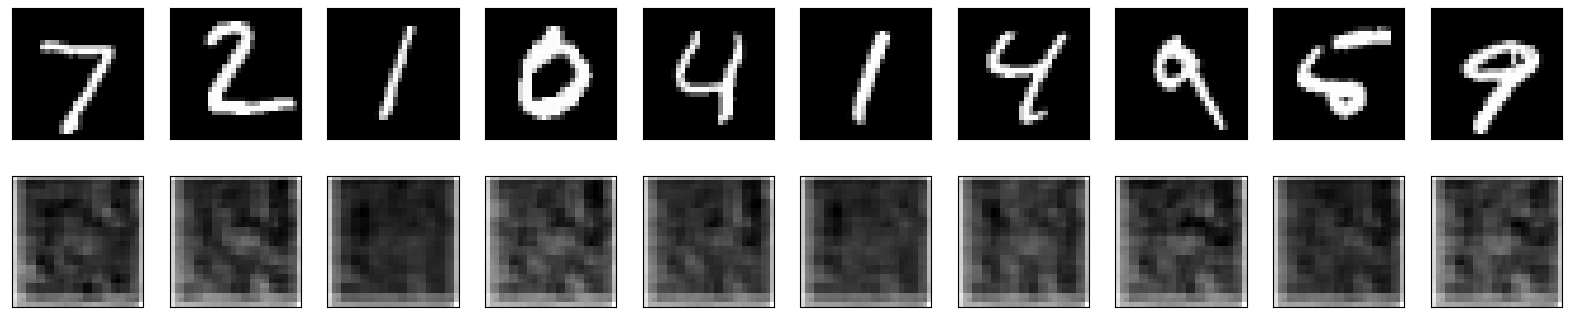

In [ ]:
# optimizer is not so good,
# epoch number should be edded

## Lab Logbook requirement:

1) Copy the autoencoder model and train it with epochs=Z+40,
where your SID is: XXXXXXZ
Leave other parameters the same as in Task 2.

2) Please only add to your Lab Logbook print-screens of:
- Table of your model autoencoder.summary()
- Code of your autoencoder.fit()
- Accuracy detailed graph
- Document the plot of the decoded images for task 2. Change the colour, appearance, and shape of the plot according to your own choice (see plt.figure() parameters).


NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.

In [20]:
from tensorflow.keras import models
autoencoder.save('Conv_autoencoder.keras')

autoencoder_2 = models.load_model('Conv_autoencoder.keras')

In [22]:
#### z = 6
history_2 = autoencoder_2.fit(
    x_train, x_train,
    epochs=46,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8087 - loss: 0.1184 - val_accuracy: 0.8072 - val_loss: 0.1172
Epoch 2/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.8089 - loss: 0.1174 - val_accuracy: 0.8082 - val_loss: 0.1159
Epoch 3/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.8091 - loss: 0.1166 - val_accuracy: 0.8081 - val_loss: 0.1152
Epoch 4/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.8093 - loss: 0.1158 - val_accuracy: 0.8085 - val_loss: 0.1145
Epoch 5/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8094 - loss: 0.1152 - val_accuracy: 0.8089 - val_loss: 0.1138
Epoch 6/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.8095 - loss: 0.1146 - val_accuracy: 0.8083 - val_loss: 0.1133
Epoch 7/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.8096 - loss: 0.1141 - val_accuracy: 0.8086 - val_loss: 0.1129
Epoch 8/46
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8097 - loss: 0.1135 - 

In [ ]:
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 30)             │       167,166 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │        14,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,647 (2.07 MB)

 Trainable params: 181,215 (707.87 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 362,432 (1.38 MB)

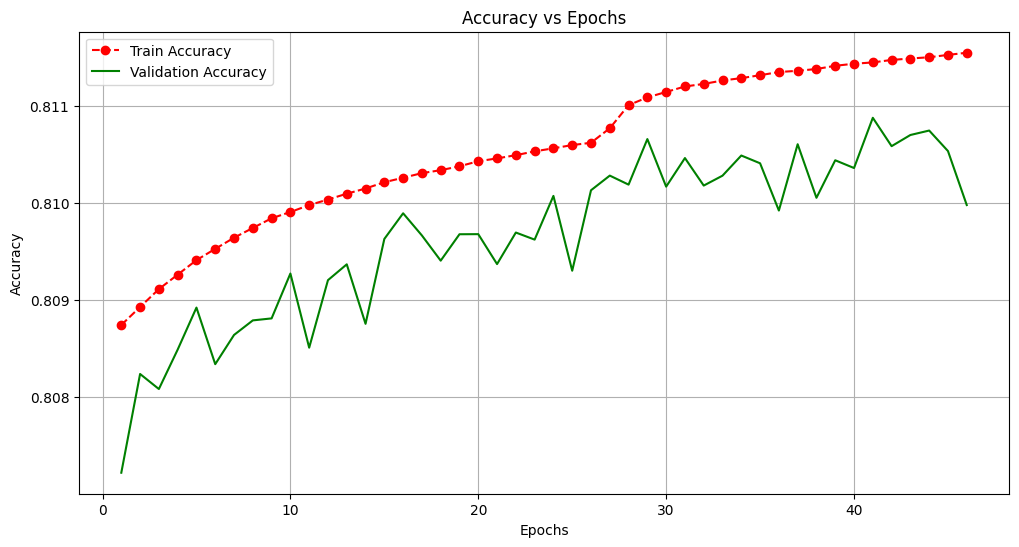

In [24]:
acc = history_2.history['accuracy']
val_acc = history_2.history['val_accuracy']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,6))

plt.plot(epochs, acc, 'ro--', label='Train Accuracy')   # red dots + dashed
plt.plot(epochs, val_acc, 'g-', label='Validation Accuracy')  # green line

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


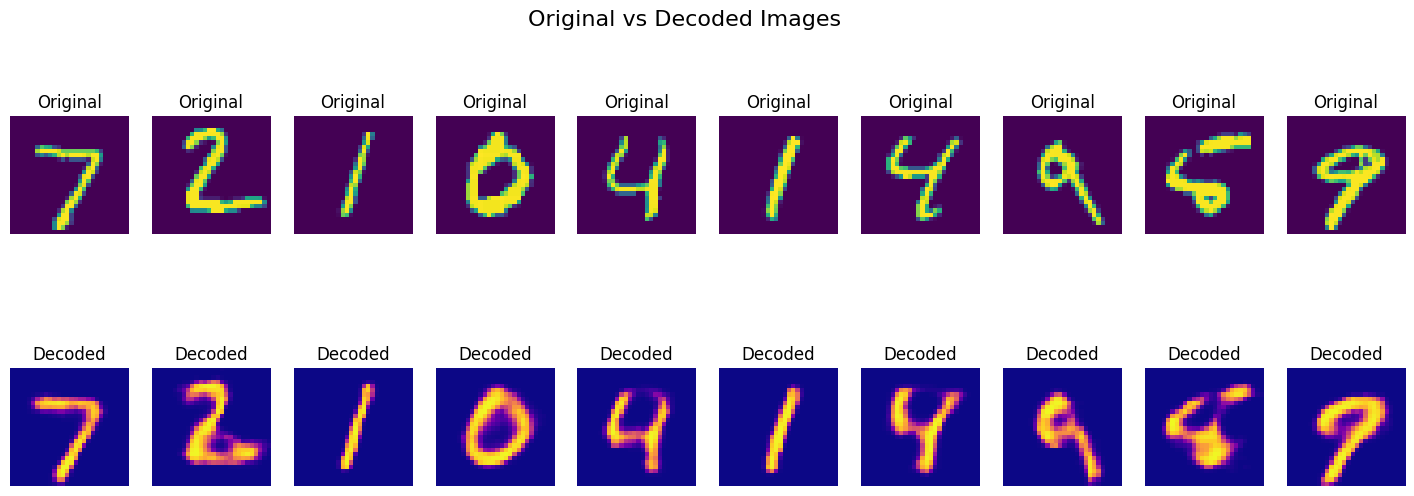

In [25]:
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(18,6))  # changed layout

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='viridis')  # changed color
    ax.set_title("Original")
    ax.axis('off')

    # Decoded
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='plasma')  # different color
    ax.set_title("Decoded")
    ax.axis('off')

plt.suptitle("Original vs Decoded Images", fontsize=16)
plt.show()